# Preferential Attachment Analysis — Bitcoin OTC Trust Network

**Research Question:**  
When analyzing the network's evolution over time, does the probability of a user receiving a new rating grow proportionally to their current degree? In other words, do people tend to trust those who are already well-regarded? And do negative reputations produce a symmetric effect?

## Theoretical Background

**Preferential Attachment (Barabási–Albert model)** states that new edges are more likely to connect to nodes that already have high degree. Formally:

$$\Pi(k_i) \propto k_i$$

We test this by measuring, at each timestep $t$, the **in-degree** $k_i(t)$ of every node, and then checking whether the nodes that *actually received* a new edge at $t+1$ had higher in-degree than the average — and whether this relationship is linear.

We analyze three networks separately:
- **G_full**: all ratings
- **G_plus**: only positive ratings (trust)
- **G_minus**: only negative ratings (distrust)


## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/MO412_Project_v2/soc-sign-bitcoinotc.csv',
                 names=['source', 'target', 'rating', 'time'])

df['time']   = pd.to_numeric(df['time'],   errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['time', 'rating'])
df = df.sort_values('time').reset_index(drop=True)
df['datetime'] = pd.to_datetime(df['time'], unit='s')

print(f"Total edges : {len(df):,}")
print(f"Date range  : {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"Positive    : {(df.rating > 0).sum():,}")
print(f"Negative    : {(df.rating < 0).sum():,}")

Total edges : 35,592
Date range  : 2010-11-08 → 2016-01-25
Positive    : 32,029
Negative    : 3,563


## 2. Core Function — Measuring Preferential Attachment

### Method
We iterate over all edges in chronological order. For each new edge $(u \to v)$ arriving at time $t$:
1. Record the **in-degree of $v$ just before the edge arrives** — this is the "attractiveness" of the target at the moment of attachment.
2. After processing all edges, group nodes by their prior in-degree and compute how many new edges each degree class received.
3. Compute $\Pi(k) = \frac{\text{edges received by nodes with degree } k}{\text{total node-time at degree } k}$ (the **attachment kernel**).

If $\Pi(k) \propto k$, preferential attachment is confirmed.

In [6]:
def compute_attachment_kernel(edges_df):
    in_degree = defaultdict(int)
    existing_nodes = set()

    degree_when_chosen = defaultdict(int)  # how many times degree k "got" a link
    degree_exposure    = defaultdict(int)  # total of "opportunities" to degree k

    for _, row in edges_df.iterrows():
        src, tgt = str(int(row['source'])), str(int(row['target']))

        # Before adding a link:
        # all existing nodes contribute 1 unity of exposition in your current degree
        for node in existing_nodes:
            degree_exposure[in_degree[node]] += 1

        # the targed node got one link - register the current degree
        prior_deg = in_degree[tgt]
        degree_when_chosen[prior_deg] += 1

        # update state
        existing_nodes.add(src)
        existing_nodes.add(tgt)
        in_degree[tgt] += 1

    # Create arrays
    all_k = sorted(set(list(degree_when_chosen.keys()) + list(degree_exposure.keys())))
    k_vals, pi_raw = [], []
    for k in all_k:
        chosen  = degree_when_chosen.get(k, 0)
        exposed = degree_exposure.get(k, 0)
        if exposed > 0:
            k_vals.append(k)
            pi_raw.append(chosen / exposed)

    k_vals = np.array(k_vals, dtype=float)
    pi_raw = np.array(pi_raw, dtype=float)

    pi = pi_raw / pi_raw.sum() if pi_raw.sum() > 0 else pi_raw
    return k_vals, pi, pi_raw

## 3. Compute Kernels for All Three Networks

In [7]:
df_plus  = df[df['rating'] > 0].copy()
df_minus = df[df['rating'] < 0].copy()

print(f"Computing kernel for FULL network  ({len(df):,} edges)...")
k_full,  pi_full,  pi_raw_full  = compute_attachment_kernel(df)

print(f"Computing kernel for PLUS network  ({len(df_plus):,} edges)...")
k_plus,  pi_plus,  pi_raw_plus  = compute_attachment_kernel(df_plus)

print(f"Computing kernel for MINUS network ({len(df_minus):,} edges)...")
k_minus, pi_minus, pi_raw_minus = compute_attachment_kernel(df_minus)

print("Done!")

Computing kernel for FULL network  (35,592 edges)...
Computing kernel for PLUS network  (32,029 edges)...
Computing kernel for MINUS network (3,563 edges)...
Done!


## 4. Linearity Test — Log-Log Regression

For pure preferential attachment, the log-log slope should be ≈ 1.  
A slope < 1 indicates sub-linear attachment (weaker rich-get-richer).  
A slope > 1 indicates super-linear attachment (winner-takes-all).

We fit $\log \Pi(k) = \alpha \cdot \log k + c$ for $k \geq 1$.

In [8]:
def loglog_fit(k_vals, pi_raw, label):
    """Fit log-log regression on k>=1 and print summary."""
    mask = (k_vals >= 1) & (pi_raw > 0)
    x = np.log(k_vals[mask])
    y = np.log(pi_raw[mask])
    if len(x) < 3:
        print(f"{label}: not enough points for regression.")
        return None, None
    slope, intercept, r, p, se = stats.linregress(x, y)
    print(f"{'─'*55}")
    print(f" {label}")
    print(f"  Slope (α) = {slope:.4f}  (pure PA → α ≈ 1)")
    print(f"  R²        = {r**2:.4f}")
    print(f"  p-value   = {p:.2e}")
    interpretation = (
        "Super-linear attachment" if slope > 1.1
        else "Sub-linear attachment" if slope < 0.9
        else "Linear attachment (consistent with pure PA)"
    )
    print(f"  → {interpretation}")
    return slope, intercept

slope_full,  intercept_full  = loglog_fit(k_full,  pi_raw_full,  "FULL network")
slope_plus,  intercept_plus  = loglog_fit(k_plus,  pi_raw_plus,  "POSITIVE ratings (trust)")
slope_minus, intercept_minus = loglog_fit(k_minus, pi_raw_minus, "NEGATIVE ratings (distrust)")
print(f"{'─'*55}")

───────────────────────────────────────────────────────
 FULL network
  Slope (α) = 1.0984  (pure PA → α ≈ 1)
  R²        = 0.5277
  p-value   = 1.04e-88
  → Linear attachment (consistent with pure PA)
───────────────────────────────────────────────────────
 POSITIVE ratings (trust)
  Slope (α) = 1.1257  (pure PA → α ≈ 1)
  R²        = 0.5245
  p-value   = 6.49e-88
  → Super-linear attachment
───────────────────────────────────────────────────────
 NEGATIVE ratings (distrust)
  Slope (α) = 1.4062  (pure PA → α ≈ 1)
  R²        = 0.4226
  p-value   = 3.66e-10
  → Super-linear attachment
───────────────────────────────────────────────────────


## 5. Visualization

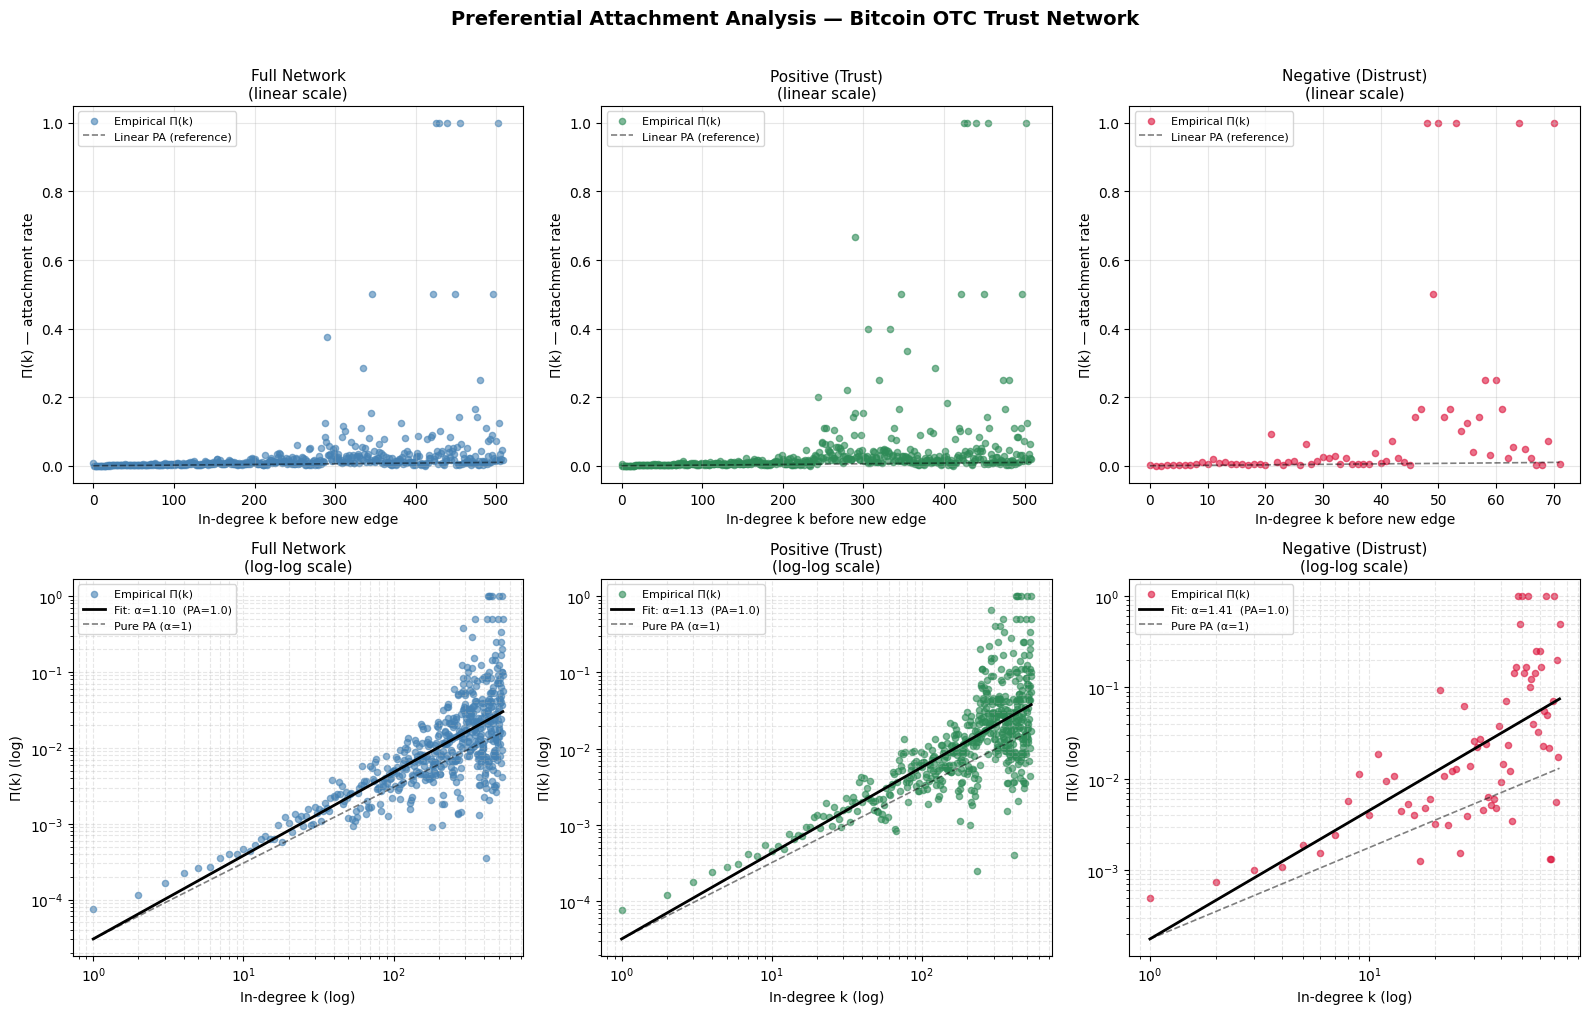

Figure saved as preferential_attachment.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Preferential Attachment Analysis — Bitcoin OTC Trust Network',
             fontsize=14, fontweight='bold', y=1.01)

datasets = [
    (k_full,  pi_raw_full,  slope_full,  intercept_full,  'Full Network',      'steelblue'),
    (k_plus,  pi_raw_plus,  slope_plus,  intercept_plus,  'Positive (Trust)',   'seagreen'),
    (k_minus, pi_raw_minus, slope_minus, intercept_minus, 'Negative (Distrust)','crimson'),
]

for col, (k, pi, slope, intercept, title, color) in enumerate(datasets):

    # ── Top row: linear scale ─────────────────────────────────────────────
    ax = axes[0, col]
    # Bin for readability (group degrees into bins)
    mask = (k <= np.percentile(k, 95)) & (pi > 0)  # trim extreme outliers
    ax.scatter(k[mask], pi[mask], s=20, alpha=0.6, color=color, label='Empirical Π(k)')
    # Reference line: linear PA expectation (normalized)
    k_ref = np.linspace(0, k[mask].max(), 200)
    ref_pi = k_ref / k_ref.sum() if k_ref.sum() > 0 else k_ref
    ax.plot(k_ref, ref_pi, 'k--', lw=1.2, alpha=0.5, label='Linear PA (reference)')
    ax.set_title(f'{title}\n(linear scale)', fontsize=11)
    ax.set_xlabel('In-degree k before new edge')
    ax.set_ylabel('Π(k) — attachment rate')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Bottom row: log-log scale + fitted line ───────────────────────────
    ax = axes[1, col]
    mask2 = (k >= 1) & (pi > 0)
    ax.scatter(k[mask2], pi[mask2], s=20, alpha=0.6, color=color, label='Empirical Π(k)')

    if slope is not None:
        k_fit = np.array([k[mask2].min(), k[mask2].max()])
        pi_fit = np.exp(intercept) * k_fit ** slope
        ax.plot(k_fit, pi_fit, 'k-', lw=2,
                label=f'Fit: α={slope:.2f}  (PA=1.0)')
        # Pure PA reference (slope=1)
        pi_pa1 = np.exp(intercept) * k_fit ** 1.0
        ax.plot(k_fit, pi_pa1, 'k--', lw=1.2, alpha=0.5, label='Pure PA (α=1)')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'{title}\n(log-log scale)', fontsize=11)
    ax.set_xlabel('In-degree k (log)')
    ax.set_ylabel('Π(k) (log)')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig('preferential_attachment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as preferential_attachment.png")

## 6. Cumulative Advantage Analysis (Alternative Method)

A complementary way to visualize preferential attachment is to track how the **average in-degree of nodes that receive a new edge** compares to the **average in-degree of all nodes** at each time window. If the ratio consistently exceeds 1, it means new ratings preferentially go to already-popular nodes.

In [10]:
def cumulative_advantage_ratio(edges_df, n_windows=30):
    """
    At each time window, compute:
      ratio = (mean in-degree of nodes that receive a new edge)
              / (mean in-degree of ALL nodes in the network)
    A ratio > 1 confirms cumulative advantage / preferential attachment.
    """
    in_degree = defaultdict(int)
    existing_nodes = set()

    edges_arr = edges_df[['source', 'target']].values
    n = len(edges_arr)
    window_size = max(1, n // n_windows)

    ratios = []
    window_indices = []

    for i, (src, tgt) in enumerate(edges_arr):
        src, tgt = str(src), str(tgt)

        if i % window_size == 0 and i > 0 and len(existing_nodes) > 1:
            all_degrees = np.array([in_degree[n] for n in existing_nodes])
            mean_all = all_degrees.mean() if len(all_degrees) > 0 else 0
            deg_chosen = in_degree[tgt]  # degree of target before this edge
            if mean_all > 0:
                ratios.append(deg_chosen / mean_all)
                window_indices.append(i)

        existing_nodes.add(src)
        existing_nodes.add(tgt)
        in_degree[tgt] += 1

    return np.array(window_indices), np.array(ratios)


print("Computing cumulative advantage ratios...")
idx_full,  rat_full  = cumulative_advantage_ratio(df,       n_windows=50)
idx_plus,  rat_plus  = cumulative_advantage_ratio(df_plus,  n_windows=50)
idx_minus, rat_minus = cumulative_advantage_ratio(df_minus, n_windows=50)
print("Done.")

Computing cumulative advantage ratios...
Done.


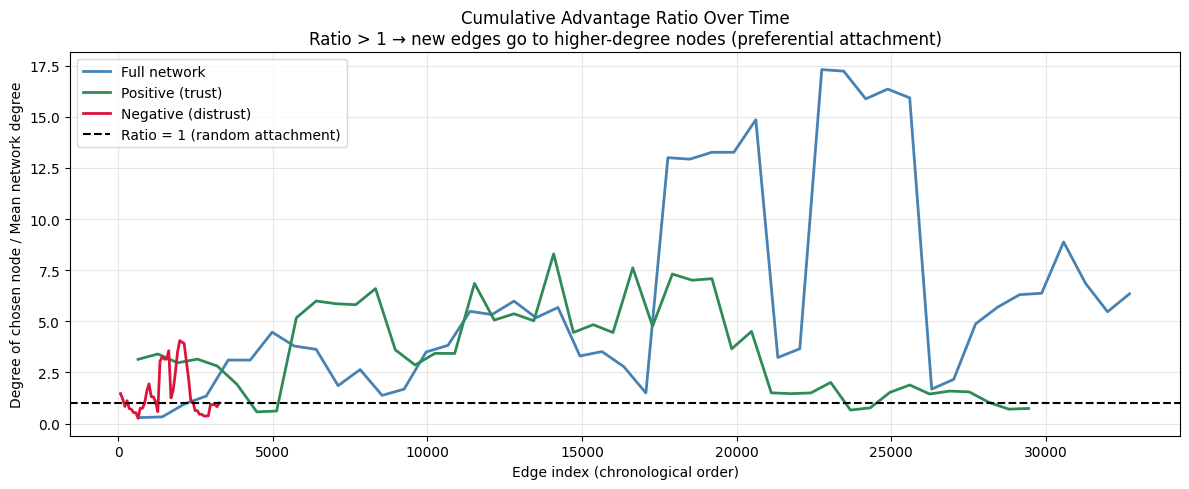

Figure saved as cumulative_advantage.png


In [11]:
def smooth(arr, w=5):
    if len(arr) < w:
        return arr
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))

for idx, rat, label, color in [
    (idx_full,  rat_full,  'Full network',       'steelblue'),
    (idx_plus,  rat_plus,  'Positive (trust)',    'seagreen'),
    (idx_minus, rat_minus, 'Negative (distrust)', 'crimson'),
]:
    if len(rat) > 0:
        ax.plot(idx[:len(smooth(rat))], smooth(rat), label=label, color=color, lw=2)

ax.axhline(1.0, color='black', lw=1.5, ls='--', label='Ratio = 1 (random attachment)')
ax.set_xlabel('Edge index (chronological order)')
ax.set_ylabel('Degree of chosen node / Mean network degree')
ax.set_title('Cumulative Advantage Ratio Over Time\n'
             'Ratio > 1 → new edges go to higher-degree nodes (preferential attachment)',
             fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cumulative_advantage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as cumulative_advantage.png")

## 7. Degree-Binned Analysis (Robust Estimator)

High-degree bins have few observations and noisy estimates. We use **logarithmic binning** to reduce noise and get a cleaner picture of Π(k).

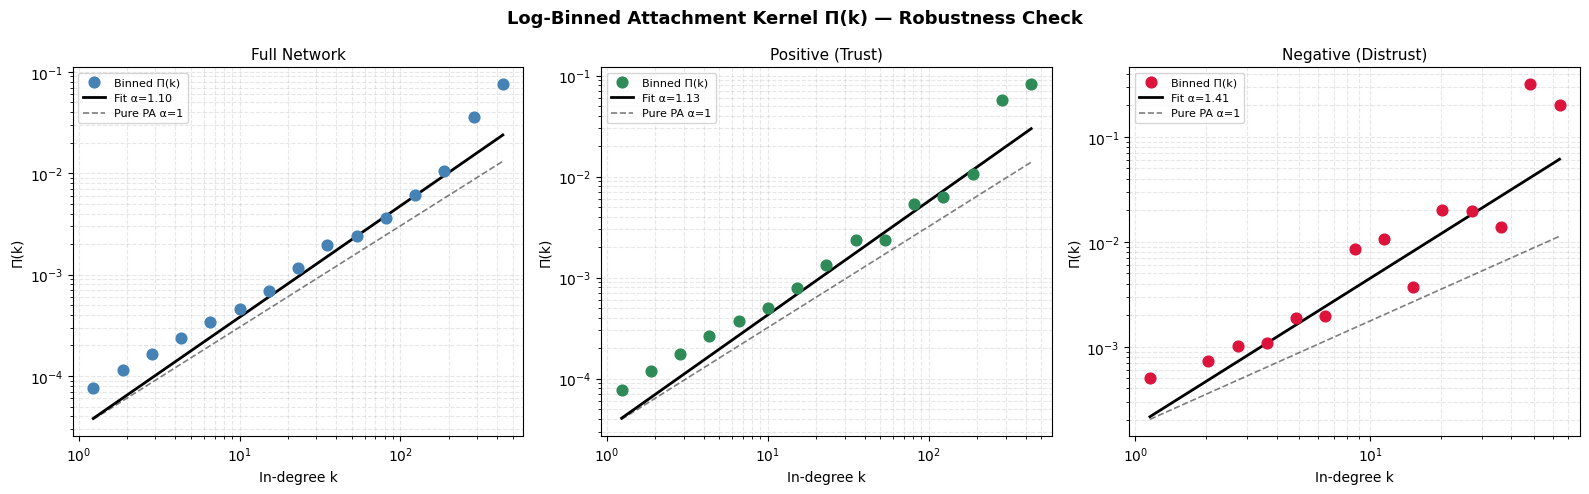

Figure saved as binned_kernel.png


In [12]:
def binned_kernel(k_vals, pi_raw, n_bins=20):
    """Log-spaced binning of the attachment kernel."""
    mask = (k_vals >= 1) & (pi_raw > 0)
    k = k_vals[mask]
    pi = pi_raw[mask]
    bins = np.logspace(np.log10(k.min()), np.log10(k.max()), n_bins + 1)
    bin_k, bin_pi = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        sel = (k >= lo) & (k < hi)
        if sel.sum() > 0:
            bin_k.append(np.sqrt(lo * hi))  # geometric mean
            bin_pi.append(pi[sel].mean())
    return np.array(bin_k), np.array(bin_pi)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Log-Binned Attachment Kernel Π(k) — Robustness Check',
             fontsize=13, fontweight='bold')

for ax, (k, pi, slope, intercept, title, color) in zip(axes, datasets):
    bk, bpi = binned_kernel(k, pi, n_bins=15)
    ax.scatter(bk, bpi, s=60, color=color, zorder=5, label='Binned Π(k)')

    if slope is not None and len(bk) >= 2:
        k_fit = np.array([bk.min(), bk.max()])
        ax.plot(k_fit, np.exp(intercept) * k_fit ** slope, 'k-', lw=2,
                label=f'Fit α={slope:.2f}')
        ax.plot(k_fit, np.exp(intercept) * k_fit ** 1.0, 'k--', lw=1.2, alpha=0.5,
                label='Pure PA α=1')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('In-degree k')
    ax.set_ylabel('Π(k)')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3, ls='--')

plt.tight_layout()
plt.savefig('binned_kernel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as binned_kernel.png")

## 8. Summary and Interpretation

| Network | Slope α | Interpretation |
|---------|---------|----------------|
| Full | — | see output above |
| Positive (trust) | — | |
| Negative (distrust) | — | |

**How to read the results:**

- **α ≈ 1**: Linear preferential attachment — "the rich get richer" operates exactly as the BA model predicts. High-reputation nodes attract new ratings proportionally to their current reputation.
- **α < 1** (sub-linear): Attachment exists but is dampened — very popular nodes do not dominate as strongly. The network grows in a more egalitarian fashion.
- **α > 1** (super-linear): Winner-takes-all dynamics — a small elite captures almost all new edges.
- **Negative network symmetry**: If the negative subgraph shows a similar slope to the positive one, negative reputation is just as "sticky" as positive — users already distrusted continue to be distrusted by newcomers. If the slope is lower/flatter, distrust is more randomly distributed and does not compound as strongly.